In [ ]:
import importlib
from RSA_nD_tuner import *
import RSA_nD_tuner
importlib.reload(RSA_nD_tuner)
from RSA_nD_tuner import *
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class ObservableDataset(Dataset):
	"""
	Converts observable dataset into PyTorch syntax.
	"""
	def __init__(self, data):
		self.data = data

	def __len__(self):
		return self.data.shape[0]

	def __getitem__(self, idx):
		sample = self.data[idx]
		return sample

In [20]:
# Paths to the datasets
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0.1_aU-0.1_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD-0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.31_N_1.0e+05_hadrons.npy'
exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.3_N_1.0e+05_hadrons.npy'
# exp_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.68_b_0.98_sigma_0.335_N_1e4.npy'
# sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# sim_hadrons_PATH       = '../data/structured_data/pgun_qqbar_hadrons_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_hadrons.npy'
# sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_accept_reject_PATH = '../data/structured_data/pgun_qqbar_mT2_accept_reject_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_id_mT2_accept_reject_z.npy'
# sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhad_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'
# sim_fPrel_PATH         = '../data/structured_data/pgun_qqbar_fPrel_a_0.72_b_0.88_sigma_0.335_N_1e4.npy'
sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0_aU0_aS0_aC0_aB0_aH0.97_bD0.98_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.335_N_1.0e+05_fPrel.npy'

# Load the arrays
exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# Print dataset shapes
print('Experimental observable shape:', exp_hadrons.shape)
print('Simulated observable shape:', sim_hadrons.shape)
print('Simulated z shape:', sim_accept_reject.shape)
print('Simulated fPrel shape:', sim_fPrel.shape)


Experimental observable shape: (100000, 75, 6)
Simulated observable shape: (100000, 75, 6)
Simulated z shape: (100000, 250, 105)
Simulated fPrel shape: (100000, 250, 100)


In [ ]:
# Define base parameters

aExtraDQuark = 0
aExtraUQuark = 0
aExtraSQuark = 0
aExtraCquark = 0
aExtraBquark = 0
aExtraDiquark = 0.97

bNonstandardD = 0.88
bNonstandardU = 0.88
bNonstandardS = 0.88
bNonstandardC = 0.88
bNonstandardB = 0.88
bNonstandardH = 0.88

aLund = 0.68
bLund = 0.98
sigma_base = 0.335

aLundD = aLund + aExtraDQuark
# bLundD = bNonstandardD
bLundD = bLund
aLundU = aLund + aExtraUQuark
# bLundU = bNonstandardU
bLundU = bLund
aLundS = aLund + aExtraSQuark
# bLundS = bNonstandardS
bLundS = bLund
aLundDiquark = aLund + aExtraDiquark
# bLundDiquark = bNonstandardH
bLundDiquark = bLund


# params_base = {'a0': torch.tensor(aLund), 'b0': torch.tensor(bLund),
params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
            'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
            'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
            'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
            'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
            'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
            'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark),
            'sigma': torch.tensor(sigma_base)}

# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU)}
params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD),'sigma': torch.tensor(sigma_base)}


r_b = torch.tensor([aLundD,bLundD,sigma_base])
r_t = torch.tensor([0.78,0.88,0.300])
s = torch.linspace(0,1,5)
s = s[:, torch.newaxis]
line_grid = r_b + s*(r_t-r_b)
line_grid = torch.tensor(line_grid)


/tmp/ipykernel_109502/3150679901.py:67: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  line_grid = torch.tensor(line_grid)


In [ ]:
#TO DO!: add repeat for error calculation

all_gradients = []
all_loss_grid = []
all_metrics_Neff = []
all_metrics_mu = []

Ns = [10,50,100]
repeat = 3
for N_events in Ns:
    for n in range(repeat):

        # Extract the hadron multiplicity
        exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])
        sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N_events)])
        # Convert into torch objects
        sim_mult_t         = torch.Tensor(sim_mult[0:N_events].copy())
        sim_accept_reject_t = torch.Tensor(sim_accept_reject[0:N_events].copy())
        sim_fPrel_t         = torch.Tensor(sim_fPrel[0:N_events].copy())
        exp_mult_t          = torch.Tensor(exp_mult[0:N_events].copy())

        # Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
        # The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
        # z = 1, this term diverges to -inf and completely destroys the backward pass.
        epsilon = 1e-5
        sim_accept_reject_t[sim_accept_reject_t == 1] = 1 - epsilon

        # Print dataset shapes
        print('Experimental multiplicity shape:', exp_mult_t.shape)
        print('Simulated multiplicity shape:', sim_mult_t.shape)
        print('Simulated z shape:', sim_accept_reject_t.shape) # only has the z values, accepted and rejected
        print('Simulated fPrel shape:', sim_fPrel_t.shape)

        # Prepare data for DataLoader
        sim_mult_t          = ObservableDataset(sim_mult_t)
        sim_accept_reject_t = ObservableDataset(sim_accept_reject_t)
        sim_mT            = ObservableDataset(sim_fPrel_t)
        exp_mult_t          = ObservableDataset(exp_mult_t)

        # Set batch size -- set it eqaul to the number of events, we only want one 'batch'
        batch_size = N_events

        # Initialize data-loaders
        sim_observable_dataloader    = DataLoader(sim_mult_t,          batch_size = batch_size, shuffle = False)
        sim_accept_reject_dataloader = DataLoader(sim_accept_reject_t, batch_size = batch_size, shuffle = False)
        sim_fPrel_dataloader         = DataLoader(sim_fPrel_t,         batch_size = batch_size, shuffle = False)
        exp_observable_dataloader    = DataLoader(exp_mult_t,          batch_size = batch_size, shuffle = False)

        # Training hyperparameters
        over_sample_factor = 10.0
        # The flow map will be dependent on the learning rate (size of the gradients)
        learning_rate = 0.01
        fixed_binning = True
        # Length of event buffer
        dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
        dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

        # Irrelevant parameters for the flow plot that must be initialized for the RSA class
        epochs = 1

        # Create an RSA instance
        RSA = RSA_nD_tuner(epochs = epochs, dim_multiplicity = dim_multiplicity, dim_accept_reject = dim_accept_reject, over_sample_factor = over_sample_factor,
                        params_base = params_base, sim_observable_dataloader = sim_observable_dataloader, sim_z_dataloader = sim_accept_reject_dataloader, 
                        sim_fPrel_dataloader = sim_fPrel_dataloader, exp_observable_dataloader = exp_observable_dataloader, print_details = False, 
                        results_dir = "/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flowmap", params_init = params_learn, fixed_binning = True)
        
        # print(a_b_init)
        # Set the optimizer
        optimizer = torch.optim.Adam(RSA.weight_nexus.parameters(), lr=learning_rate)
        #optimizer = torch.optim.SGD(macroscopic_trainer.weight_nexus.parameters(), lr=learning_rate)
        # Generate gradients
        a_b_gradients, loss_grid, metrics = RSA.RSA_flow(optimizer, line_grid)
        all_gradients.append(a_b_gradients)
        all_loss_grid.append(loss_grid)
        all_metrics_mu.append(metrics[0])
        all_metrics_Neff.append(metrics[1])

a_b_c = line_grid.detach().numpy()

plt_nm = 2
# np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}',all_gradients)
# np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}',all_loss_grid)
# np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}',all_metrics_mu)
# np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}',all_metrics_Neff)
# np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}',Ns)
# np.save(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}',a_b_c)



Experimental multiplicity shape: torch.Size([10])
Simulated multiplicity shape: torch.Size([10])
Simulated z shape: torch.Size([10, 250, 105])
Simulated fPrel shape: torch.Size([10, 250, 100])


  0%|                                                                         | 0/5 [00:00<?, ?it/s]

{'a1': tensor(0.6800), 'b1': tensor(0.9800), 'sigma': tensor(0.3350)}


/pscratch/sd/l/ljpuslar/RSA/RSA/src/lund_weight_nD_temp.py:234: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mT2 = torch.tensor(z_mT2_pid[:, :, 2],dtype=a_base.dtype)
 60%|███████████████████████████████████████                          | 3/5 [00:00<00:00,  6.92it/s]

----------------------------------------------
Loss: 2.5000002
0.68
0.98
0.335
----------------------------------------------
{'a1': tensor(0.7050), 'b1': tensor(0.9550), 'sigma': tensor(0.3263)}
----------------------------------------------
Loss: 2.6359367
0.705
0.95500004
0.32625002
----------------------------------------------
{'a1': tensor(0.7300), 'b1': tensor(0.9300), 'sigma': tensor(0.3175)}
----------------------------------------------
Loss: 2.8608541
0.73
0.93
0.3175
----------------------------------------------
{'a1': tensor(0.7550), 'b1': tensor(0.9050), 'sigma': tensor(0.3088)}


...

----------------------------------------------
Loss: 0.8342619
0.73
0.93
0.3175
----------------------------------------------
{'a1': tensor(0.7550), 'b1': tensor(0.9050), 'sigma': tensor(0.3088)}


 80%|████████████████████████████████████████████████████             | 4/5 [00:02<00:00,  1.38it/s]

----------------------------------------------
Loss: 0.8606288
0.755
0.905
0.30875
----------------------------------------------
{'a1': tensor(0.7800), 'b1': tensor(0.8800), 'sigma': tensor(0.3000)}


100%|█████████████████████████████████████████████████████████████████| 5/5 [00:03<00:00,  1.38it/s]

----------------------------------------------
Loss: 0.87439644
0.78
0.88
0.3
----------------------------------------------


In [ ]:
# Plot only one set of simulated data

plt_nm = 3
all_gradients = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_gradients{plt_nm}.npy')
all_loss_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_loss_grid{plt_nm}.npy')
all_metrics_mu = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_mu_metrics{plt_nm}.npy', allow_pickle=True)
all_metrics_Neff = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Neff_metrics{plt_nm}.npy', allow_pickle=True)
Ns = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_Ns{plt_nm}.npy', allow_pickle=True)
line_grid = np.load(f'/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/grad_stability/all_line_grid{plt_nm}.npy', allow_pickle=True)

# Plot different components of gradient for chosen point on line grid
plt.figure()
point = 0
for i in range(np.shape(all_gradients)[2]):
    plt.plot(Ns, -all_gradients[:,point,i],'-o', label=f'{i}')
plt.legend()

# Plot chosen grad component of gradient for all points on line grid
plt.figure()
grad = 2
for i in range(np.shape(all_gradients)[1]):
    plt.plot(Ns, -all_gradients[:,i,grad],'-o', label=f'{i}')
plt.legend()

# Plot loss value for all points on line grid
plt.figure()
for i in range(np.shape(all_loss_grid)[1]):
    plt.plot(Ns, all_loss_grid[:,i], label=f'{i}')
plt.legend()

# Plot metrics value for all points on line grid
plt.figure()
for i in range(np.shape(all_metrics_Neff)[1]):
    plt.plot(Ns, all_metrics_Neff[:,i], label=f'{i}')
plt.legend()


NameError: name 'np' is not defined

10
50
100
500
1000
2500
5000
7500
10000
25000


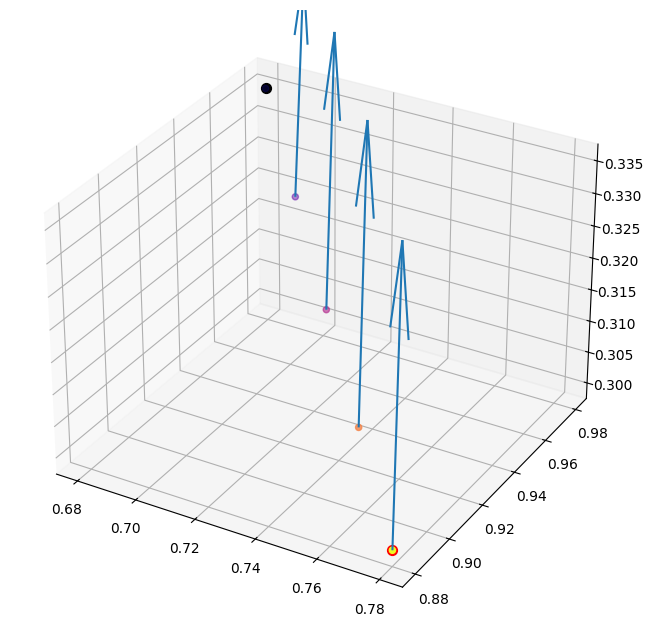

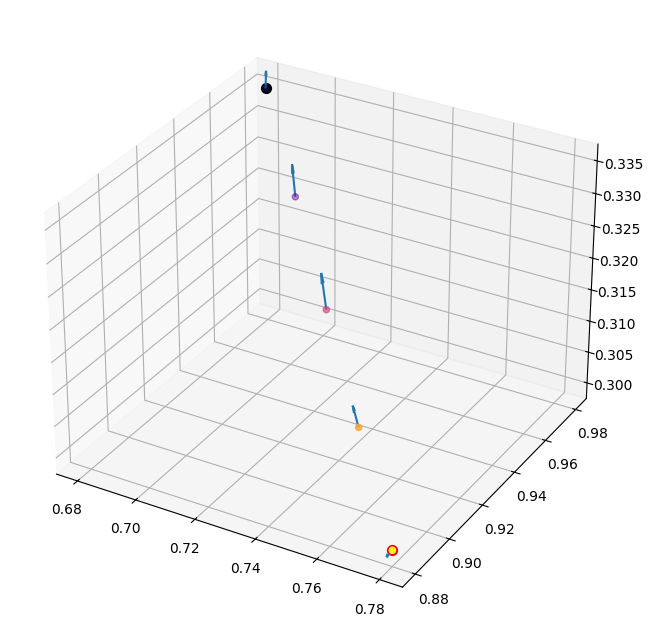

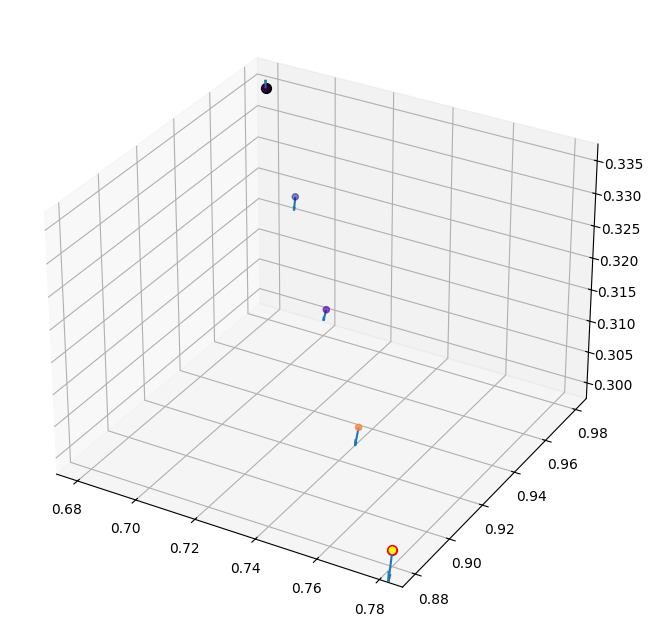

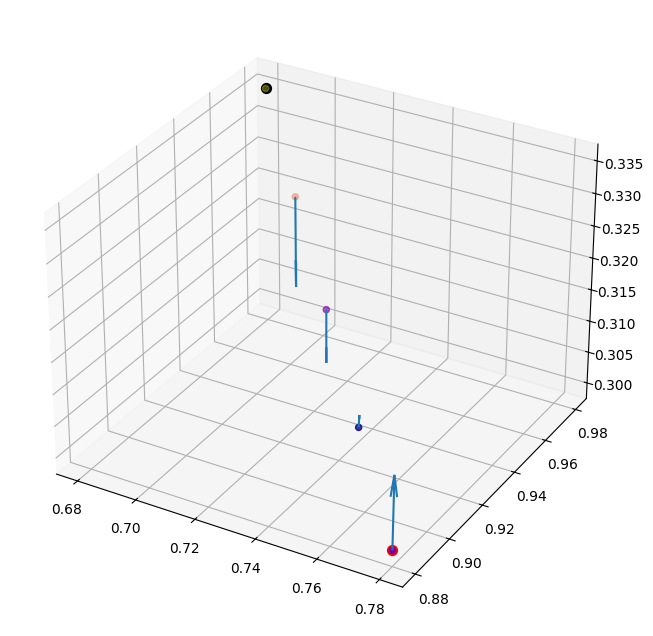

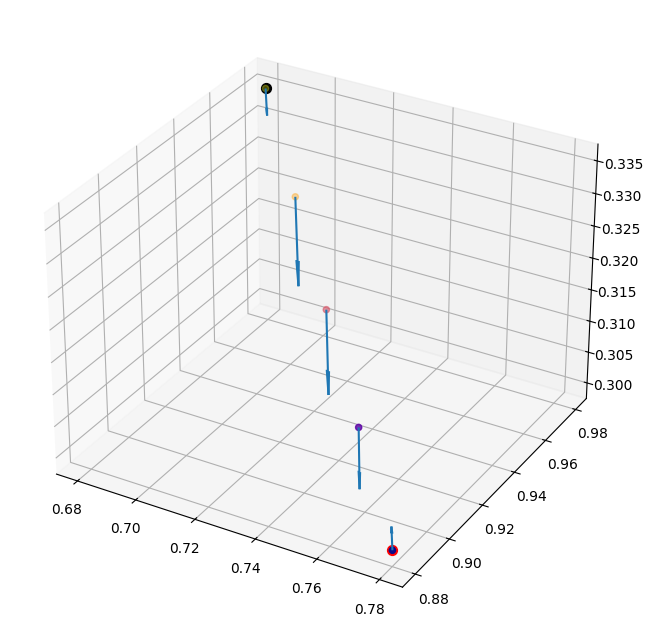

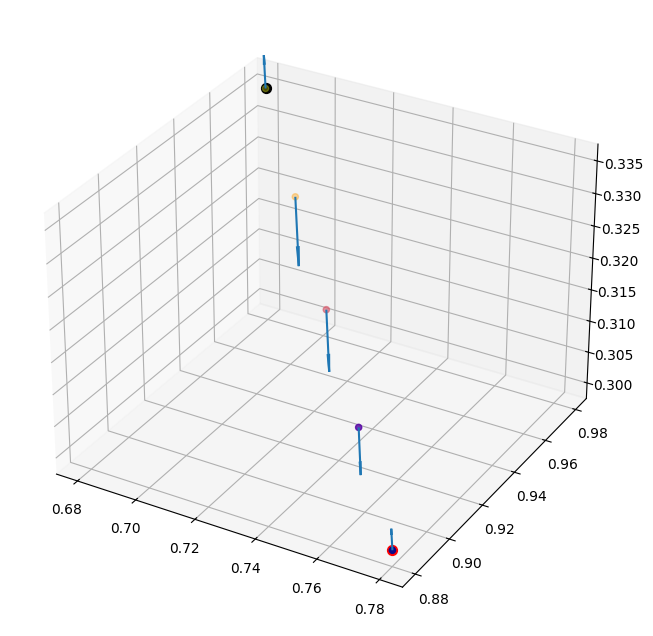

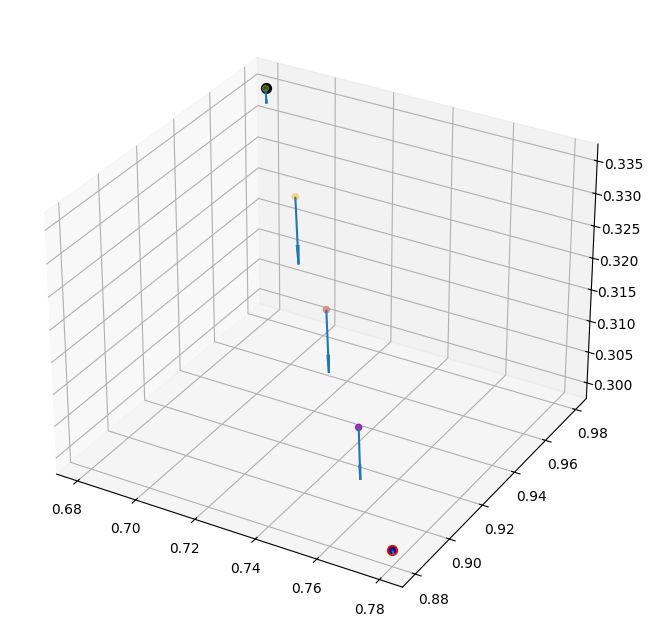

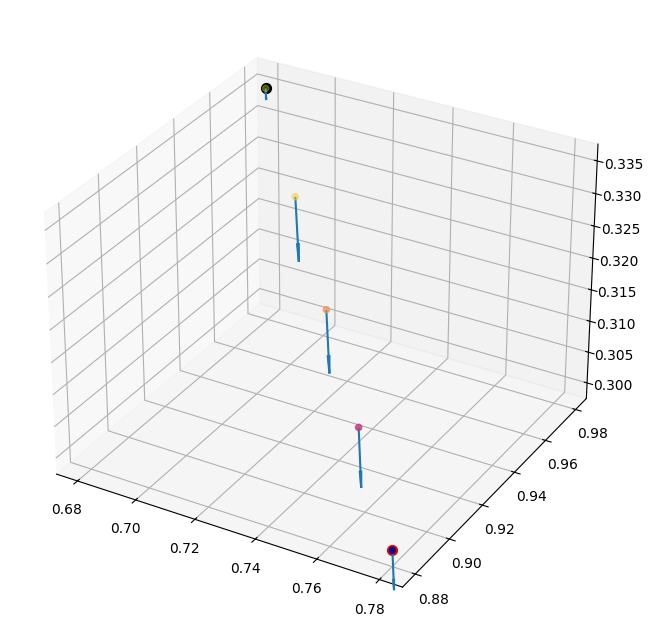

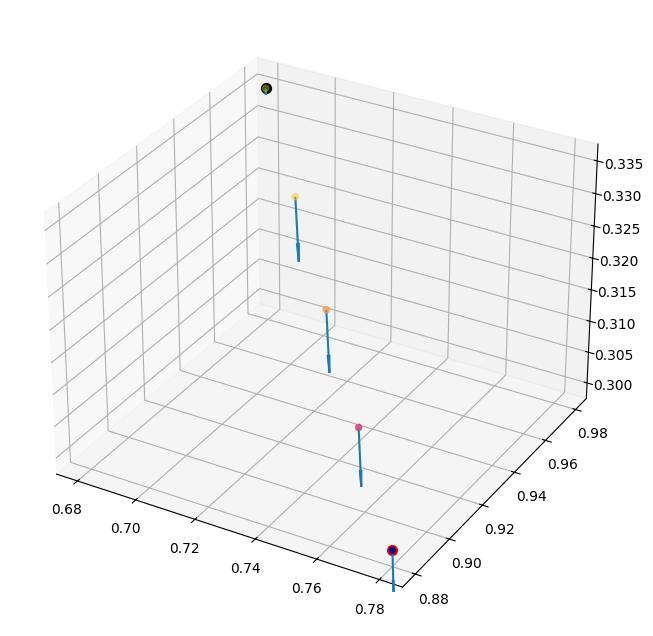

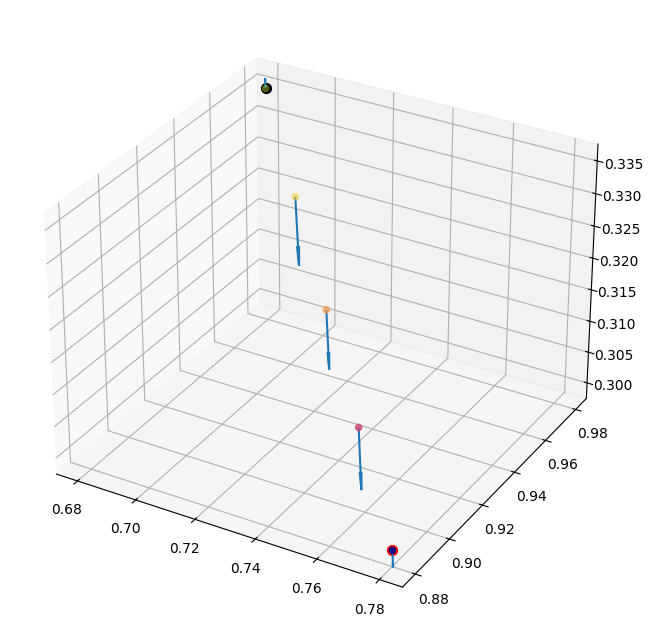

In [ ]:
# Plot gradients for points on line_grid in 3D

a_b_c = line_grid

for ind, N in enumerate(Ns):
    fig = plt.figure(figsize=(10, 8))

    a_b_gradients = all_gradients[ind]
    loss_grid = all_loss_grid[ind]


    ax = fig.add_subplot(111, projection='3d')

    ad = a_b_c[:,0]
    bd = a_b_c[:,1]
    sig = a_b_c[:,2]

    g1,g2,g3 =  -a_b_gradients[:,0], -a_b_gradients[:,1], -a_b_gradients[:,2],
    scale = 10e2
    ax.quiver(ad,bd,sig,g1/scale,g2/scale,g3/scale)
    # sc = ax.scatter(ad, bd, sig, c=magnitudes, cmap='plasma', s=20)  # 's' is size, 'c' is color
    sc = ax.scatter(ad, bd, sig, c=np.log10((loss_grid)), cmap='plasma', s=20)  # 's' is size, 'c' is color
    ax.scatter(0.68,0.98,0.335, label = 'base', c= 'black', s=50)
    ax.scatter(0.78,0.88,0.300, label = 'target', c='red', s=50)
    ax.set_title(f'{N}')